# 01b — Single-SP preprocessing (PASS Plan A ported to Curtin WVSP)
Direct port of `Pre-processing_A_run3_geophone.ipynb`, adapted for one shot gather at a time.

Keeps every PASS design decision:
- **Step 0**: DAS strain-rate → v_z via Tikhonov-regularized k_z-domain integrator
  `H(k_z) = -i k_z / (k_z² + λ²)`, λ=2π/Lc. (Plain cumsum is unstable → horizontal striping.)
- **Step 3**: first breaks from the csv (= sonic fb column), interpolated per channel by DEPTH.
  No straight-ray prediction, no onset search — the csv already lives in the data's time frame.
- **fk**: full apparent-velocity cone + low-f cut + k-notch, `direction='up'`, depth_positive_down=False.
- Near-channel constant scaling.

Set `SP` below and run top to bottom → saves `work/rtm_input_das_spXX.bin` for RTM/FWI.
Run the first cell first: it prints dimensions so you can confirm channel/depth/time counts.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
sys.path.insert(0, os.path.abspath('.'))
from curtin_wvsp_utils import load_sonic

WORK = './work'
SP = 23                      # <-- shot to process (near offset). Change and rerun for other SPs.
DATASET = 'das'              # 'das' (strain-rate, needs Step 0) or 'geo' (already v_z, skips Step 0)
dt = float(np.load(f'{WORK}/dt.npy')[0])

# correlated single-shot gather from NB00  (channel axis 0 = depth, time axis 1)
eps = np.load(f'{WORK}/corr_{DATASET}_sp{SP}.npy').astype(np.float32)
depth = np.load(f'{WORK}/x_{DATASET}_sp{SP}.npy').astype(float)
nr, nt = eps.shape
dz = float(np.median(np.diff(depth)))

# sonic / csv picks
S = load_sonic('./Data/Curtin_DAS_VSP_Sonic_modified.csv')

# per-SP source offset (horizontal distance well->source), from NB00 export
offs = np.load(f'{WORK}/sp_offsets.npy')
OFF = {int(s_): o_ for s_, o_ in offs}
offset = OFF[SP]
print(f'  source offset (horizontal) = {offset:.1f} m')

print(f'SP {SP} [{DATASET}]  gather = {eps.shape}  (nchan={nr}, ntime={nt})')
print(f'  depth {depth.min():.1f}-{depth.max():.1f} m,  dz={dz:.2f} m,  dt={dt*1e3:.1f} ms')
print(f'  csv: {len(S["depth"])} rows, depth {S["depth"].min():.1f}-{S["depth"].max():.1f} m, '
      f'fb {np.nanmin(S["tv"]):.4f}-{np.nanmax(S["tv"]):.4f} s')
print(f'  csv depth covers gather: {depth.min() >= S["depth"].min()-10 and depth.max() <= S["depth"].max()+10}')

  source offset (horizontal) = 159.5 m
SP 23 [das]  gather = (161, 3001)  (nchan=161, ntime=3001)
  depth 85.3-902.0 m,  dz=5.10 m,  dt=1.0 ms
  csv: 883 rows, depth 0.0-900.5 m, fb 0.0000-0.4081 s
  csv depth covers gather: True


## Step 0 — DAS strain-rate → v_z (Tikhonov k_z integrator)
Ported verbatim from PASS. `Lc` is the only knob (~60–150 m); smaller Lc removes more
low-k_z drift. Geophone data skip this (already particle velocity).

In [2]:
def das_rate_to_vz(eps_rate, dz, Lc=100.0, pad=64):
    e = np.asarray(eps_rate, float)
    ep = np.pad(e, ((pad, pad), (0, 0)), mode='reflect')
    n = ep.shape[0]
    kz = 2*np.pi*np.fft.fftfreq(n, d=float(dz))
    lam = 2*np.pi/float(Lc)
    H = (-1j*kz)/(kz**2 + lam**2)
    vz = np.fft.ifft(np.fft.fft(ep, axis=0)*H[:, None], axis=0).real
    return vz[pad:-pad].astype(np.float32)

Lc = 100.0
if DATASET == 'das':
    data1 = das_rate_to_vz(eps, dz, Lc=Lc)
else:
    data1 = eps.copy()          # geophone: already v_z
print('v_z shape:', data1.shape)

v_z shape: (161, 3001)


## Step 0b — round-trip QC
`d(v_z)/dz` vs input strain-rate should overlap (per-channel corr > 0.9). DAS only.

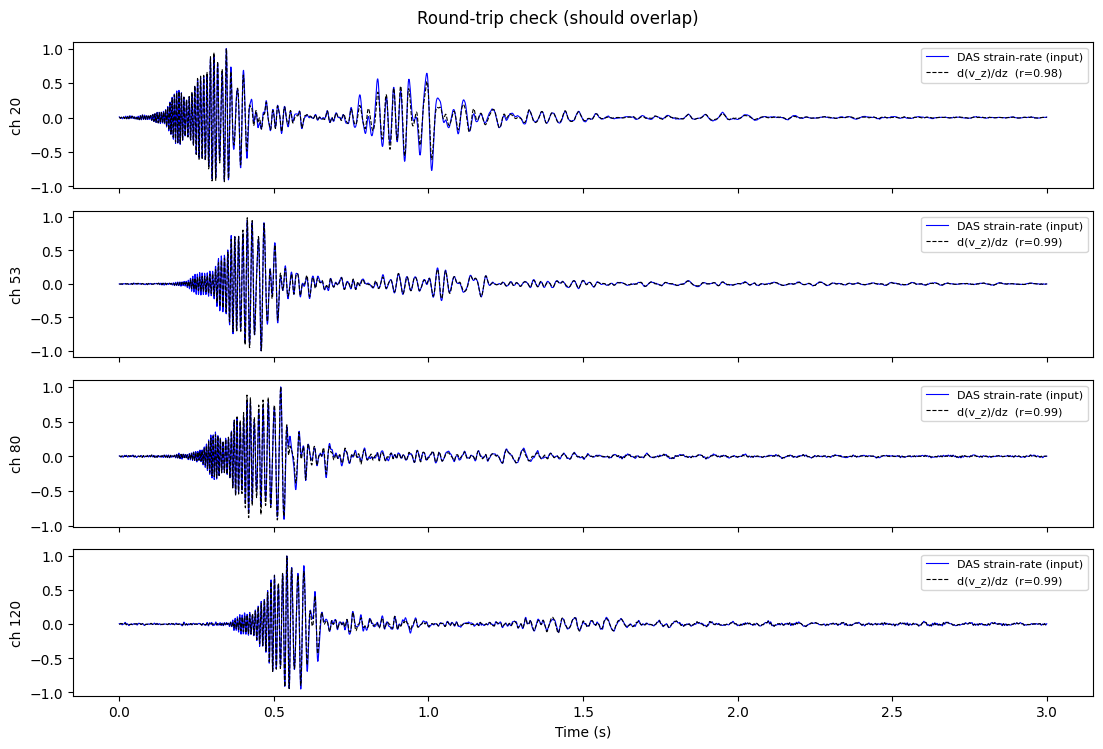

In [3]:
if DATASET == 'das':
    chans = [c for c in [nr//8, nr//3, nr//2, 3*nr//4] if c < nr]
    tt = np.arange(nt)*dt
    nrm = lambda x: x/(np.max(np.abs(x))+1e-12)
    eps_rt = np.gradient(data1.astype(float), dz, axis=0)
    fig, ax = plt.subplots(len(chans), 1, figsize=(11, 1.9*len(chans)), sharex=True)
    for a, c in zip(np.atleast_1d(ax), chans):
        cc = np.corrcoef(eps[c], eps_rt[c])[0, 1]
        a.plot(tt, nrm(eps[c]), 'b', lw=0.8, label='DAS strain-rate (input)')
        a.plot(tt, nrm(eps_rt[c]), 'k--', lw=0.8, label=f'd(v_z)/dz  (r={cc:.2f})')
        a.set_ylabel(f'ch {c}'); a.legend(loc='upper right', fontsize=8)
    np.atleast_1d(ax)[-1].set_xlabel('Time (s)')
    fig.suptitle('Round-trip check (should overlap)'); plt.tight_layout(); plt.show()
else:
    print('geophone: Step 0b skipped')

## Step 1 — denoise: median across depth

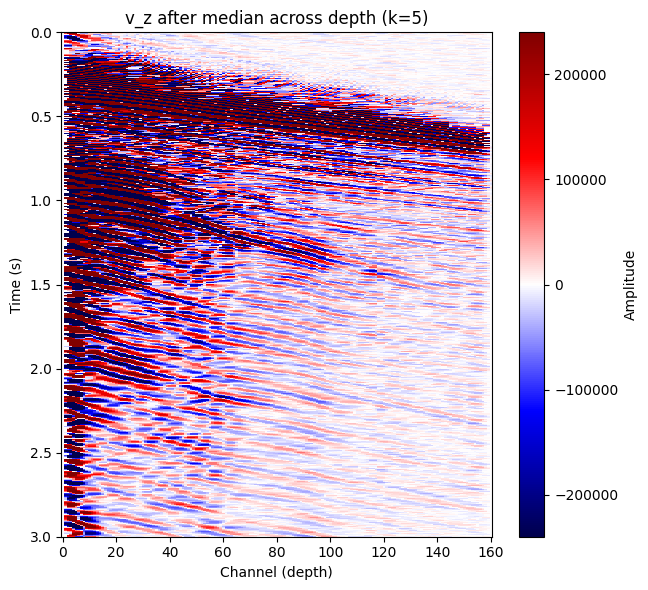

In [4]:
def show(G, title):
    nr_, nt_ = G.shape; r = np.arange(nr_); t = np.arange(nt_)*dt
    vmax = np.percentile(np.abs(G), 85)
    plt.figure(figsize=(6.6, 6))
    plt.pcolormesh(r, t, G.T, shading='nearest', cmap='seismic', vmin=-vmax, vmax=vmax)
    plt.gca().invert_yaxis(); plt.colorbar(label='Amplitude')
    plt.xlabel('Channel (depth)'); plt.ylabel('Time (s)'); plt.title(title)
    plt.tight_layout(); plt.show()

k_depth = 5
if k_depth % 2 == 0: k_depth += 1
pad = k_depth//2
Gp = np.pad(data1, ((pad, pad), (0, 0)), mode='edge')
W = sliding_window_view(Gp, window_shape=(k_depth, Gp.shape[1]))[:, 0, :, :]
data1_dn = np.median(W, axis=1).astype(data1.dtype, copy=False)
show(data1_dn, f'v_z after median across depth (k={k_depth})')

## Step 2 — band-limit (10–150 Hz)

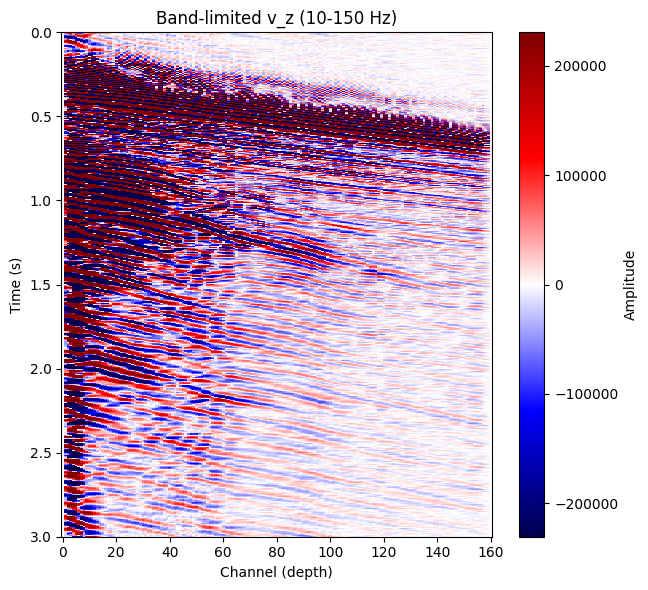

In [5]:
fmin, fmax = 10.0, 150.0
def bandpass_fft(G, dt, fmin, fmax):
    nt_ = G.shape[1]
    F = np.fft.rfftfreq(nt_, d=dt)
    mask = (F >= fmin) & (F <= fmax)
    return np.fft.irfft(np.fft.rfft(G, axis=1)*mask[None, :], n=nt_, axis=1)

data_bp = bandpass_fft(data1_dn, dt, fmin, fmax)
show(data_bp, f'Band-limited v_z ({fmin:.0f}-{fmax:.0f} Hz)')

## Step 3 — first breaks from per-source straight-ray geometry
The csv `fb`/`Vertical travel time` column is the **vertical** traveltime (offset = 0), the
SAME for every shot — using it directly is wrong: real first breaks depend on source-receiver
distance, so a far shot arrives later than a near one.

Straight-ray traveltime from a surface source at horizontal `offset` to a receiver at depth z:

    t(z) = slant_distance / v_avg(z) = sqrt(z² + offset²) / v_avg(z)

`v_avg(z)` = average velocity to depth z, taken from the sonic (depth / vertical_traveltime).
This is per-SP: each shot gets its own picks from its own offset.

SP 23 offset 160 m:  fb 114-414 ms  (vertical-only would be 54-408 ms)


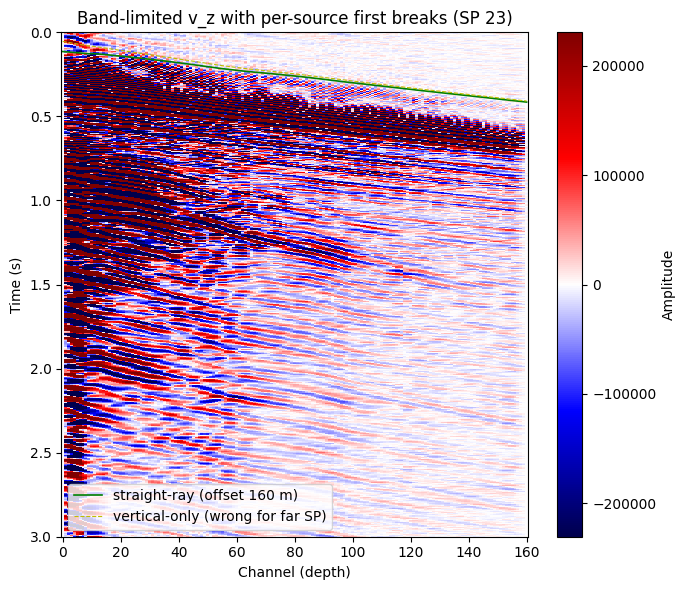

In [6]:
# average velocity to each depth from sonic vertical traveltime
tv_vert = np.interp(depth, S['depth'], S['tv'])                 # vertical traveltime (s)
v_avg = np.where(tv_vert > 1e-6, depth/np.maximum(tv_vert, 1e-6), np.nan)
v_avg = np.clip(v_avg, 1200., 6000.)

# straight-ray slant traveltime for THIS source's offset
slant = np.sqrt(depth**2 + offset**2)
fb_time_full = slant / v_avg                                   # s, per channel, per-SP
fb_idx = np.clip(np.round(fb_time_full/dt).astype(int), 0, nt-1)
print(f'SP {SP} offset {offset:.0f} m:  fb {fb_time_full.min()*1e3:.0f}-{fb_time_full.max()*1e3:.0f} ms  '
      f'(vertical-only would be {tv_vert.min()*1e3:.0f}-{tv_vert.max()*1e3:.0f} ms)')

# QC overlay
t = np.arange(nt)*dt; r = np.arange(nr)
vmax = np.percentile(np.abs(data_bp), 85)
plt.figure(figsize=(7, 6))
plt.pcolormesh(r, t, data_bp.T, shading='nearest', cmap='seismic', vmin=-vmax, vmax=vmax)
plt.plot(r, fb_time_full, 'g-', lw=1.2, label=f'straight-ray (offset {offset:.0f} m)')
plt.plot(r, tv_vert, 'y--', lw=0.8, label='vertical-only (wrong for far SP)')
plt.gca().invert_yaxis(); plt.colorbar(label='Amplitude')
plt.xlabel('Channel (depth)'); plt.ylabel('Time (s)')
plt.title(f'Band-limited v_z with per-source first breaks (SP {SP})'); plt.legend(); plt.tight_layout(); plt.show()

## Step 3b — first-break geometry check across all sources

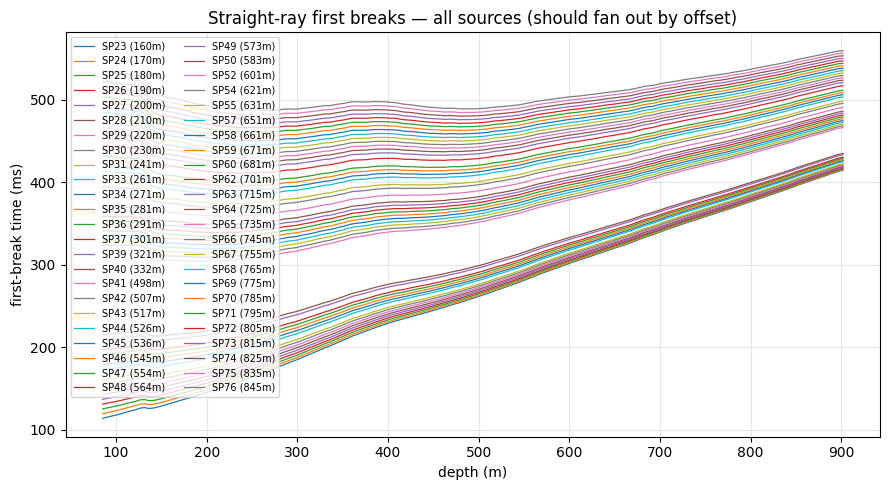

near SP -> steep/early, far SP -> late/flat. If all curves overlap, offset is not being applied.


In [7]:
# ---- verify first breaks across ALL sources (geometry check) ----
# Each SP's straight-ray picks must differ by its own offset: far SP later & flatter.
offs_all = np.load(f'{WORK}/sp_offsets.npy')
plt.figure(figsize=(9, 5))
for sp_, off_ in offs_all:
    sp_ = int(sp_)
    xf = f'{WORK}/x_das_sp{sp_}.npy'
    if not os.path.exists(xf):
        continue
    dep = np.load(xf).astype(float)
    tvv = np.interp(dep, S['depth'], S['tv'])
    va = np.clip(np.where(tvv > 1e-6, dep/np.maximum(tvv, 1e-6), np.nan), 1200., 6000.)
    fb_ = np.sqrt(dep**2 + off_**2)/va
    plt.plot(dep, fb_*1e3, lw=0.9, label=f'SP{sp_} ({off_:.0f}m)')
plt.xlabel('depth (m)'); plt.ylabel('first-break time (ms)')
plt.title('Straight-ray first breaks — all sources (should fan out by offset)')
plt.legend(fontsize=7, ncol=2, loc='upper left'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print('near SP -> steep/early, far SP -> late/flat. If all curves overlap, offset is not being applied.')

## Step 3.2 — estimate downgoing: align → depth-median → unalign

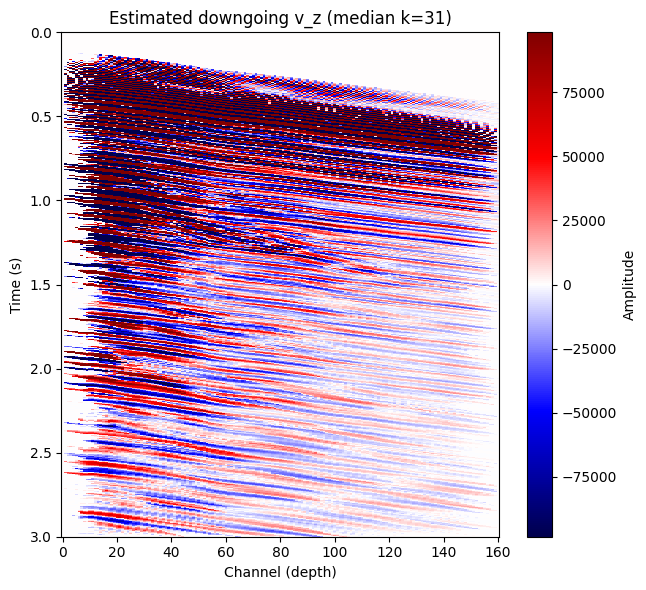

In [8]:
k_median = 31
def align_by_fb(G, fb):
    nr_, nt_ = G.shape; out = np.zeros_like(G)
    for i in range(nr_):
        s = int(fb[i])
        if 0 <= s < nt_: out[i, :nt_-s] = G[i, s:]
    return out
def unalign_by_fb(Ga, fb):
    nr_, nt_ = Ga.shape; out = np.zeros_like(Ga)
    for i in range(nr_):
        s = int(fb[i])
        if 0 <= s < nt_: out[i, s:] = Ga[i, :nt_-s]
    return out
def depth_running_median(Ga, k=31):
    if k % 2 == 0: k += 1
    pad = k//2
    Gp = np.pad(Ga, ((pad, pad), (0, 0)), mode='edge')
    W = sliding_window_view(Gp, window_shape=(k, Gp.shape[1]))[:, 0, :, :]
    return np.median(W, axis=1)

aligned = align_by_fb(data_bp, fb_idx)
down_est = unalign_by_fb(depth_running_median(aligned, k=k_median), fb_idx)
show(down_est, f'Estimated downgoing v_z (median k={k_median})')

## Step 3.3 — subtract downgoing → upgoing residual

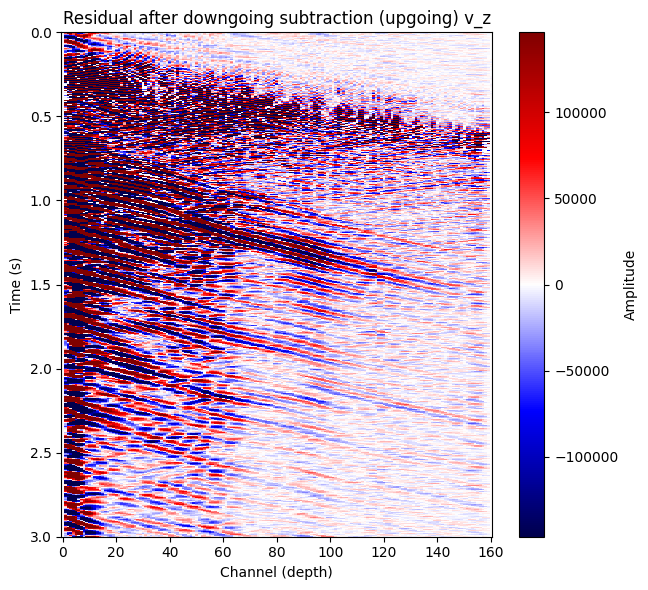

In [9]:
upgoing_0 = data_bp - down_est
show(upgoing_0, 'Residual after downgoing subtraction (upgoing) v_z')

## Step 4 — f-k up/down separation
Ported verbatim. `depth_positive_down=False` and the cone/lowcut/notch params are PASS run3.
**If the 'kept' panel still shows the downgoing direct arrival, flip `depth_positive_down`.**

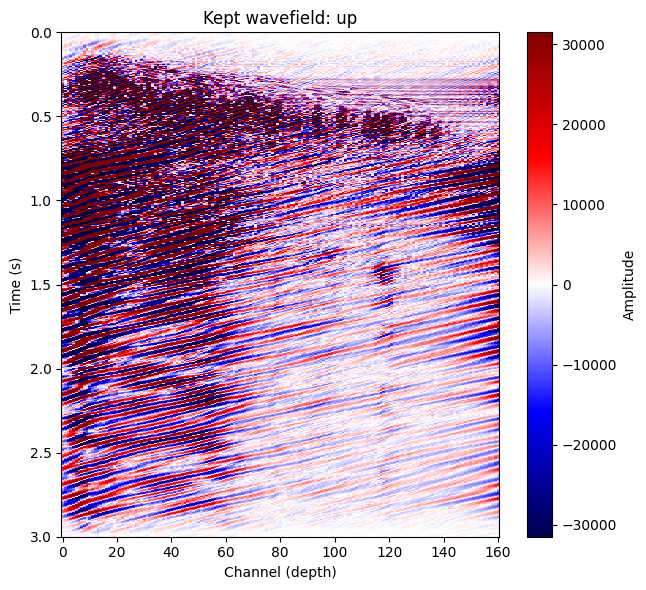

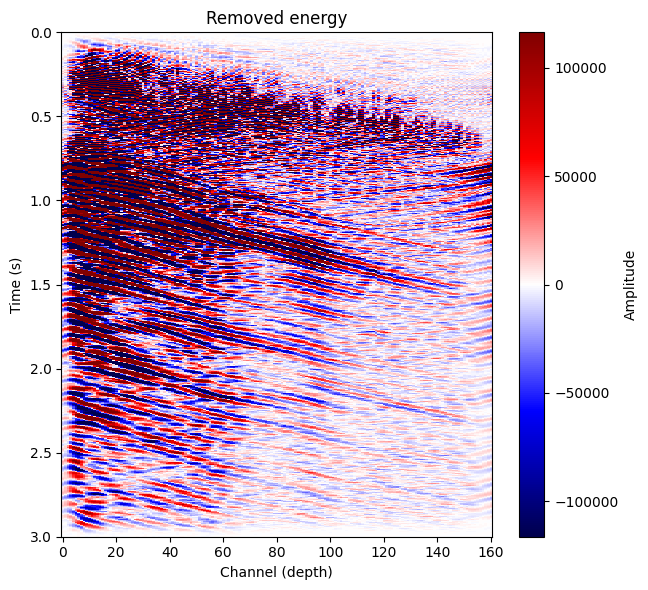

In [10]:
def cosine_taper_1d(n, frac=0.1):
    frac = float(np.clip(frac, 0.0, 0.5)); m = int(frac*n); w = np.ones(n)
    if m > 0:
        ramp = 0.5*(1 - np.cos(np.pi*np.arange(m)/m)); w[:m] = ramp; w[-m:] = ramp[::-1]
    return w
def soft_keep_inside_cone(v_app, vcut, width):
    x = np.clip((vcut - v_app)/max(width, 1e-12), -1.0, 1.0)
    return 0.5*(1.0 + np.cos(np.pi*np.maximum(0.0, 1.0 - (x+1.0)/2.0)))
def fk_keep_direction(G, dt, dz, direction='up', depth_positive_down=True,
                      v_app_max=3000.0, v_taper=400.0, lowcut_hz=2.0, k_notch=0.02,
                      depth_taper=0.10, time_taper=0.05):
    nr_, nt_ = G.shape; r = np.arange(nr_); t = np.arange(nt_)*dt
    G_taper = G * (cosine_taper_1d(nr_, depth_taper)[:, None] *
                   cosine_taper_1d(nt_, time_taper)[None, :])
    Gk = np.fft.fft2(G_taper, axes=(0, 1))
    f = np.fft.fftfreq(nt_, d=dt); k = np.fft.fftfreq(nr_, d=dz)
    K, F = np.meshgrid(k, f, indexing='ij')
    with np.errstate(divide='ignore', invalid='ignore'):
        v_app = np.abs(F)/(np.abs(K)+1e-12)
    if depth_positive_down:
        up_cond, down_cond = (F*K) < 0, (F*K) > 0
    else:
        up_cond, down_cond = (F*K) > 0, (F*K) < 0
    dir_mask = up_cond if direction == 'up' else down_cond
    cone = soft_keep_inside_cone(v_app, v_app_max, v_taper)
    lowf = (np.abs(F) >= lowcut_hz).astype(float)
    knotch = (np.abs(K) >= k_notch).astype(float)
    mask = cone * lowf * knotch * dir_mask.astype(float)
    G_keep = np.fft.ifft2(Gk*mask, axes=(0, 1)).real
    G_removed = G_taper - G_keep
    def _show(D, title):
        vmax = np.percentile(np.abs(D), 85)
        plt.figure(figsize=(6.6, 6))
        plt.pcolormesh(r, t, D.T, shading='nearest', cmap='seismic', vmin=-vmax, vmax=vmax)
        plt.gca().invert_yaxis(); plt.colorbar(label='Amplitude')
        plt.xlabel('Channel (depth)'); plt.ylabel('Time (s)'); plt.title(title)
        plt.tight_layout(); plt.show()
    _show(G_keep, f'Kept wavefield: {direction}')
    _show(G_removed, 'Removed energy')
    return G_keep, G_removed

G_up, _ = fk_keep_direction(upgoing_0, dt, dz, direction='up', depth_positive_down=False,
                            v_app_max=1800, v_taper=400, lowcut_hz=2, k_notch=0.01)

## Step 5 — first-break mute

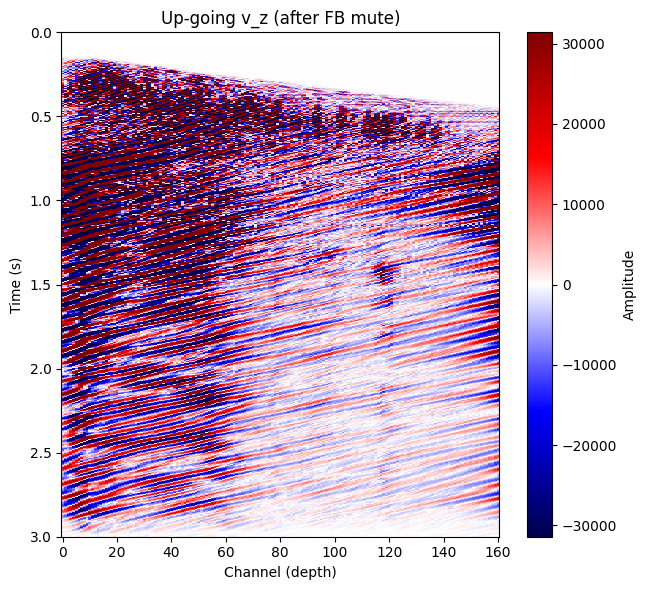

In [11]:
guard, taper = 0.020, 0.050
guard_samp = int(round(guard/dt)); tap_samp = max(1, int(round(taper/dt)))
M = np.zeros_like(G_up)
for i in range(nr):
    i0 = fb_idx[i] + guard_samp; i1 = min(i0 + tap_samp, nt)
    if i0 < nt:
        if i1 > i0:
            M[i, i0:i1] = 0.5*(1 - np.cos(np.pi*np.linspace(0, 1, i1-i0, endpoint=False)))
        M[i, i1:] = 1.0
G_up_muted = G_up * M
show(G_up_muted, 'Up-going v_z (after FB mute)')

## Step 6 — constant scaling for near channels

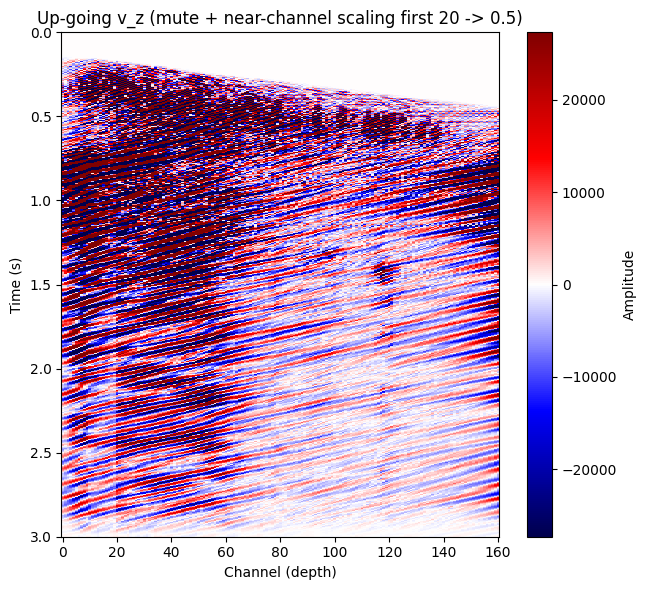

In [12]:
N_CONST = 20      # first N channels scaled down (near-well / shallow noise)
SCALE = 0.5
mask = np.ones(nr); mask[:min(N_CONST, nr)] = SCALE
G_up_scaled = G_up_muted * mask[:, None]
show(G_up_scaled, f'Up-going v_z (mute + near-channel scaling first {N_CONST} -> {SCALE})')

## Save processed upgoing gather for RTM/FWI

In [13]:
rtm_input = G_up_scaled.astype(np.float32, copy=False)
# also save downgoing (for FWI transmission) and the picks
os.makedirs(WORK, exist_ok=True)
np.save(f'{WORK}/proc_up_{DATASET}_sp{SP}.npy', rtm_input)
np.save(f'{WORK}/proc_down_{DATASET}_sp{SP}.npy', down_est.astype(np.float32))
np.save(f'{WORK}/picks_{DATASET}_sp{SP}.npy', fb_time_full)
np.save(f'{WORK}/x_proc_{DATASET}_sp{SP}.npy', depth)
rtm_input.tofile(f'{WORK}/rtm_input_{DATASET}_sp{SP}.bin')
print(f'saved SP {SP} [{DATASET}]: {rtm_input.shape}  '
      f'-> proc_up/proc_down/picks/x_proc .npy + rtm_input .bin')

saved SP 23 [das]: (161, 3001)  -> proc_up/proc_down/picks/x_proc .npy + rtm_input .bin
